## Import libraries


In [5]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hydrokit.utils import create_grids, create_domain
from hydrokit.input.watershed import get_dem, calculate_flow_metrics

import warnings

warnings.filterwarnings("ignore")

## Load the region and create grids


(25, 4)


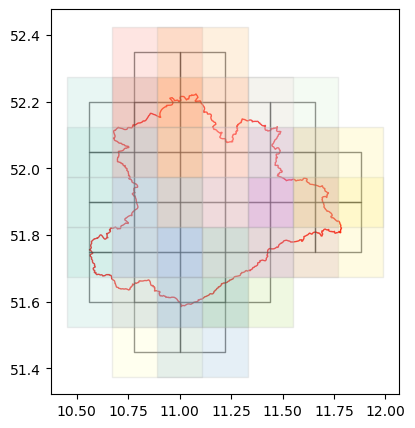

In [6]:
roi_path = (
    "/beegfs/halder/GITHUB/PROJECT/hydrokit/data/raw/study_area/Bode_catchment.zip"
)
roi = gpd.read_file(roi_path)

lat_resolution = 0.15
lon_resolution = 0.22

grid_gdf = create_grids(roi, lat_resolution, lon_resolution)
domain_gdf = create_domain(
    grid_gdf, lat_buffer=lat_resolution * 0.5, lon_buffer=lon_resolution * 0.5
)

print(grid_gdf.shape)

fig, ax = plt.subplots(figsize=(5, 5))
roi.plot(ax=ax, facecolor="none", edgecolor="red")
grid_gdf.plot(ax=ax, facecolor="none", alpha=0.5)
domain_gdf.plot(ax=ax, column="ID", cmap="Set3", alpha=0.2, edgecolor="darkgrey")

plt.show()

## Download and process DEM data


In [7]:
# Extract bounding box from the first grid cell
bbox = list(domain_gdf.iloc[-1].geometry.bounds)

# Download DEM data
dem_path = "test_dem.tif"
dem = get_dem(bbox=bbox, out_path=dem_path)

Found 2 items
DEM saved to test_dem.tif


## Prepare flow direction and accumulation


In [8]:
fdir, acc = calculate_flow_metrics(dem_path, "test_fdir.tif", "test_acc.tif")

Filling pits...
Filling depressions...
Resolving flats...
Calculating flow direction...
Calculating flow accumulation...
Saving flow direction to test_fdir.tif...
Saving flow accumulation to test_acc.tif...
Processing complete!
